## Practical work - IA in bioscience - Practical 1
# From loading data to learning from these data

The objective of this lab is to lead you through a Machine Learning workflow, from getting the data, looking at them and understanding them to applying machine learning algoritms to make predictions.

We will use the language Python. I suggest you use Jupyter to write your code (keep in mind that it may be very convenient to prototype stuff, but not so much for large scale project). In a Jupyter notebook, an output is produced each time you execute a cell (a block a code). For instance, if you want to print the last 5 lines of a pandas dataset, you can just write `data.tail(5)` but you will have to use the function `print()` if you use another IDE.

Feel free to use any other IDE available to you if you are more confortable with them.

During this lab, you should keep the documentations of both Pandas, Scikit-learn and TensorFlow at hand.

## Pick a question
When you work on data, you probably have a specific question to anwser (such as "is there a cat in this photo?", "based on the color and how firm this avocado is, is it edible?" or "given the last 7 values of Anybrand stock, should I buy or sell?"

You will then have to define a question you want to answer with your model. But first, let's have a look at the data.


# Exploratory data analysis

Before we start working on the data, let's load them. We are going to use the Python library Pandas [https://pandas.pydata.org/](https://pandas.pydata.org/):
> pandas is an open source, BSD-licensed library providing high-performance, easy-to-use data structures and data analysis tools for the Python programming language.

Pandas will load your dataset into a dataframe. We will first use this dataframe to get an idea of what's in the data.

Download the dataset `housing.csv` available on Moodle, then execute the following code snippet.

In [ ]:
import pandas as pd
from   pandas.plotting import scatter_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:

np.random.seed(42) # set the seed for reproducibility

#root = "/path/to/working/directory/" # you'll have to adapt this to your workking directory

root = ""

df = pd.read_csv(root + "AVONET.csv")

df.head()

,Species3,Family3,Order3,Total.individuals,Female,Male,Unknown,Complete.measures,Beak.Length_Culmen,Beak.Length_Nares,...,Migration,Trophic.Level,Trophic.Niche,Primary.Lifestyle,Min.Latitude,Max.Latitude,Centroid.Latitude,Centroid.Longitude,Range.Size,Species.Status
0,Accipiter albogularis,Accipitridae,Accipitriformes,5,2,0,3,4,27.7,17.8,...,2.0,Carnivore,Vertivore,Insessorial,-11.73,-4.02,-8.15,158.49,37461.21,Extant
1,Accipiter badius,Accipitridae,Accipitriformes,10,4,6,0,8,20.6,12.1,...,3.0,Carnivore,Vertivore,Insessorial,-29.47,46.39,8.23,44.98,22374973.00,Extant
2,Accipiter bicolor,Accipitridae,Accipitriformes,6,2,2,2,4,26.5,14.8,...,2.0,Carnivore,Vertivore,Generalist,NaN,NaN,NaN,NaN,NaN,Extant
3,Accipiter brachyurus,Accipitridae,Accipitriformes,4,4,0,0,3,22.5,14.0,...,2.0,Carnivore,Vertivore,Insessorial,-6.31,-4.08,-5.45,150.68,35580.71,Extant
4,Accipiter brevipes,Accipitridae,Accipitriformes,8,4,4,0,4,21.1,12.1,...,3.0,Carnivore,Vertivore,Generalist,31.19,55.86,45.24,45.33,2936751.80,Extant


## Questions
1. What is the result of calling the method `head()` on the dataframe ?
2. Call the method `info()` on your dataframe
  1. How many instances are there in the dataset ?
  2. How many attributes ?
  3. Are the attributes numerical ? Categorical ?
  4. Are some values missing for any attributes ?
3. What does an instance of this dataset represent ??

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9993 entries, 0 to 9992
Data columns (total 35 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Species3            9993 non-null   object 
 1   Family3             9993 non-null   object 
 2   Order3              9993 non-null   object 
 3   Total.individuals   9993 non-null   int64  
 4   Female              9993 non-null   int64  
 5   Male                9993 non-null   int64  
 6   Unknown             9993 non-null   int64  
 7   Complete.measures   9993 non-null   int64  
 8   Beak.Length_Culmen  9993 non-null   float64
 9   Beak.Length_Nares   9993 non-null   float64
 10  Beak.Width          9993 non-null   float64
 11  Beak.Depth          9993 non-null   float64
 12  Tarsus.Length       9993 non-null   float64
 13  Wing.Length         9993 non-null   float64
 14  Kipps.Distance      9993 non-null   float64
 15  Secondary1          9993 non-null   float64
 16  Tail.L

Check the number of unique value for each column.

8. What kind of data has the least number of unique values ?
9. Are there some exceptions ?

In [ ]:
df.nunique(axis=0)


,0
Species3,9993
Family3,194
Order3,40
Total.individuals,120
Female,47
Male,67
Unknown,76
Complete.measures,45
Beak.Length_Culmen,944
Beak.Length_Nares,773


## Choosing the questions
Remember the "what question" thing ? Now it's time to pick one. **Given this dataset, what questions would you like to anwser once you have a trained model ?**



## Initial cleaning of the data

### Dropping columns

Some columns are unlikely to be relevant for the task at hand (be it predicting a variable from other variable, or classification). In this case, it may be best to remove them from the dataset to reduce the size of the dataframe and avoid including unneeded data in the data analysis.

Note that you may always have to remove column after performing more analysis, if it appear they are problematic.

Identify and remove the column you obviously won't need here.

In [ ]:
df = df.drop(columns=[ 'Family3', 'Order3', 'Total.individuals', 'Female', 'Male', 'Unknown', 'Complete.measures', 'Mass.Source',
                      'Mass.Refs.Other', 'Inference', 'Traits.inferred','Reference.species', 'Species.Status'])


In [ ]:
df

,Species3,Beak.Length_Culmen,Beak.Length_Nares,Beak.Width,Beak.Depth,Tarsus.Length,Wing.Length,Kipps.Distance,Secondary1,Tail.Length,...,Habitat.Density,Migration,Trophic.Level,Trophic.Niche,Primary.Lifestyle,Min.Latitude,Max.Latitude,Centroid.Latitude,Centroid.Longitude,Range.Size
0,Accipiter albogularis,27.7,17.8,10.6,14.7,62.0,235.2,81.8,159.5,169.0,...,1.0,2.0,Carnivore,Vertivore,Insessorial,-11.73,-4.02,-8.15,158.49,37461.21
1,Accipiter badius,20.6,12.1,8.8,11.6,43.0,186.7,62.5,127.4,140.6,...,2.0,3.0,Carnivore,Vertivore,Insessorial,-29.47,46.39,8.23,44.98,22374973.00
2,Accipiter bicolor,26.5,14.8,9.2,13.5,57.5,231.8,46.4,189.6,188.4,...,2.0,2.0,Carnivore,Vertivore,Generalist,NaN,NaN,NaN,NaN,NaN
3,Accipiter brachyurus,22.5,14.0,8.9,11.9,61.2,202.2,64.1,138.1,140.8,...,1.0,2.0,Carnivore,Vertivore,Insessorial,-6.31,-4.08,-5.45,150.68,35580.71
4,Accipiter brevipes,21.1,12.1,8.7,11.1,46.4,217.6,87.8,129.9,153.5,...,1.0,3.0,Carnivore,Vertivore,Generalist,31.19,55.86,45.24,45.33,2936751.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9988,Trogon personatus,18.9,11.7,8.5,8.9,14.3,125.7,46.9,78.3,157.8,...,1.0,1.0,Omnivore,Omnivore,Insessorial,-20.40,11.16,-2.92,-71.92,745904.62
9989,Trogon rufus,19.9,11.7,8.9,9.8,13.1,113.1,42.8,70.3,130.9,...,1.0,1.0,Omnivore,Omnivore,Insessorial,-29.64,16.03,-5.73,-61.12,6666233.02
9990,Trogon surrucura,19.5,11.8,9.3,9.9,15.3,133.2,51.2,82.0,132.7,...,1.0,1.0,Carnivore,Invertivore,Insessorial,-31.18,-10.87,-22.48,-49.89,1550766.21
9991,Trogon violaceus,19.3,11.6,9.8,8.9,11.5,115.1,42.5,72.6,117.4,...,1.0,1.0,Herbivore,Frugivore,Insessorial,-15.61,10.84,-3.51,-62.89,5916744.71


### Handling missing values

Some of the columns have missing values. Machine Learning models cannot process those, so we can:
* remove the instances with missing values `dropna()`
* remove the attribute `drop()`
* fill the blanks `fillna()`

No option is inherently better than the others... It depends (as always) on the problem. You can try the different options and see if you have different results with your learning model.

Here we noted that the number of missing value is small compared to the size of the dataset. We can remove them.

In [ ]:
df = df.dropna()

## Understanding the data

### Numerical attributes

Execute the following instruction and explain what each line represents in terms of statistics :

In [ ]:
df.describe()

,Beak.Length_Culmen,Beak.Length_Nares,Beak.Width,Beak.Depth,Tarsus.Length,Wing.Length,Kipps.Distance,Secondary1,Tail.Length,Mass,Habitat.Density,Migration,Min.Latitude,Max.Latitude,Centroid.Latitude,Centroid.Longitude,Range.Size
count,9787.000000,9787.000000,9787.000000,9787.000000,9787.000000,9787.000000,9787.000000,9787.00000,9787.000000,9787.000000,9787.000000,9787.000000,9787.000000,9787.000000,9787.000000,9787.000000,9.787000e+03
mean,26.483785,17.142025,6.585021,8.081956,29.006968,126.017278,37.706478,88.15069,87.193512,266.995228,1.755390,1.293757,-7.120821,12.227116,3.008175,16.367650,2.800250e+06
std,24.938136,20.612041,5.177331,7.656962,25.121860,95.121641,46.118926,58.58120,62.390462,1624.582223,0.782133,0.624492,22.757142,23.700985,22.487546,87.471495,7.915488e+06
min,4.500000,1.600000,0.900000,1.000000,2.500000,0.100000,0.100000,0.10000,0.100000,1.900000,1.000000,1.000000,-85.580000,-65.120000,-71.040000,-178.410000,8.800000e-01
25%,14.600000,8.500000,3.600000,3.800000,17.500000,66.600000,10.900000,53.10000,50.100000,15.000000,1.000000,1.000000,-23.175000,-2.780000,-10.020000,-68.385000,7.479965e+04
50%,19.900000,11.700000,5.000000,5.800000,22.000000,92.000000,19.700000,70.20000,68.300000,35.700000,2.000000,1.000000,-8.370000,9.620000,-0.320000,20.890000,5.252892e+05
75%,28.600000,18.000000,7.700000,9.500000,31.700000,146.500000,44.000000,100.90000,100.600000,124.650000,2.000000,1.000000,7.960000,23.615000,15.665000,103.135000,2.576351e+06
max,414.200000,389.800000,88.900000,110.900000,475.000000,789.900000,417.800000,629.10000,812.800000,111000.000000,3.000000,3.000000,68.080000,85.010000,78.430000,179.080000,1.363044e+08


Execute the following instruction to plot [histograms](https://en.wikipedia.org/wiki/Histogram) for each attributes:

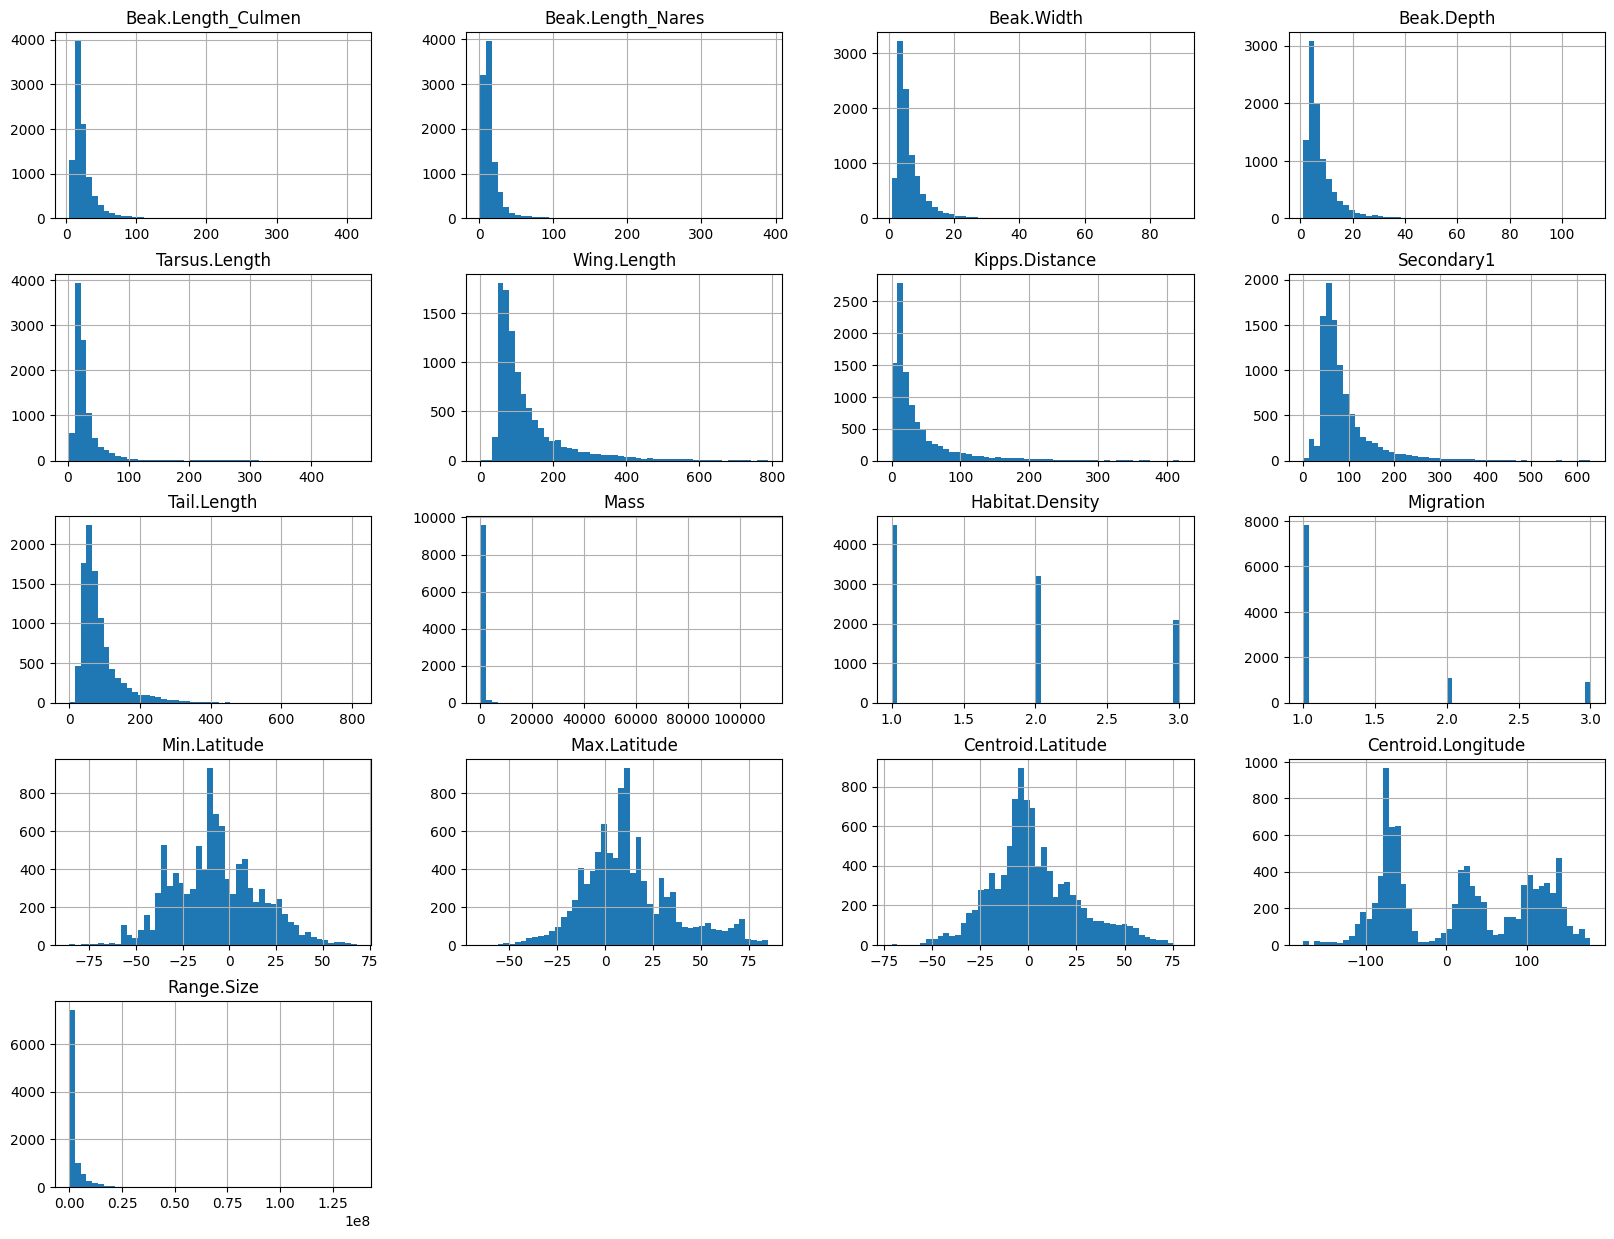

In [ ]:
#for jupyter :
%matplotlib inline
df.hist(bins=50, figsize=(20,15))
plt.show() # optional if using jupyter

### Questions
1. Are all attributes on the same scale ?
2. What can you say about 'Habitat.Density' and 'Migration' ?
3. How should these variable be treated ?
4. Look at the distributions for the attributes `Centroid.Longitude`. How can you explain this ?
5. Most histograms are left-skewed. Can you guess what kind of distribution shape is ideal for our data when working with statistics and machine learning ?

[An interesting discussion about skewed data](https://stats.stackexchange.com/questions/267078/why-is-skewed-data-not-preferred-for-modelling)

As you probably noted, the attribute `Habitat` looks like a categorical attribute. Execute the following instruction and explain the output:

### Outliers

### Transforming attributes

We noticed centroid longitude is a problematic variable that might be more useful as a categorical one. Let's transform it.
The data are roughly trimodal, we can divide it in three categories one from -200 to -25, -25 to 60, 60 to 200.

For this, we can use the method `cut()` from pandas:
> Bin values into discrete intervals.
> Use cut when you need to segment and sort data values into bins. This function is also useful for going from a continuous variable to a categorical variable. For example, cut could convert ages to groups of age ranges. Supports binning into an equal number of bins, or a pre-specified array of bins.

In [ ]:
df['Centroid.Longitude'] = pd.cut(df['Centroid.Longitude'],
                          bins=[-200,-25,60,np.inf], # bins edges
                          labels=['West', 'Greenwich', 'East'])

<ipython-input-103-512d735913fa>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Centroid.Longitude'] = pd.cut(df['Centroid.Longitude'],


### Looking for correlations

The two following instructions compute the correlation between every pair of attributes.
You can look at how attributes are correlated to a target (here `Mass`).

Correlations are coefficients ranging from -1 to 1. A correlation close to 1 (resp. -1) means that there is a strong positive (resp. negative) correlation between the attribute and the target.
In other words, a positive correlation between X and Y means that Y tends to increase when X increases. A negative correlation between X and Y means that Y tends to decrease when X increases. A value near 0 means there's no correlation.

*Keep in mind that we are only talking about **linear** correlations here.*

In [ ]:
corr_matrix = df.corr(numeric_only=True)

### Questions
1. Assuming that we want to predict the mass of a bird species from the rest of informations available, what is the most correlated attribute to this value ?
2. Are there any other attributes strongly linearly correlated to the mmass of a bird ?
3. Are machine learning models able to learn non linear correlations in data ?

In [ ]:
corr_matrix['Mass'].sort_values(ascending=False)

,Mass
Mass,1.000000
Tarsus.Length,0.566638
Secondary1,0.420196
Wing.Length,0.386075
Beak.Width,0.349770
Beak.Length_Culmen,0.333202
Tail.Length,0.275282
Beak.Depth,0.274885
Beak.Length_Nares,0.262110
Kipps.Distance,0.260259


### Questions
1. Assuming that we want to predict the mass of any bird from its dimension, what is the most correlated attribute to this value ?
2. Are there any other attributes strongly linearly correlated to the mass of a bird ?
3. Are machine learning models able to learn non linear correlations in data ?

### Correlation between all variables

We can plot the correlation matrix between our numerical data, to consider whether some of the attributes are redundant.
Using heatmaps allow to quickly visualize correlation between all values in our dataset

<Axes: title={'center': 'Correlation of numerical features'}>

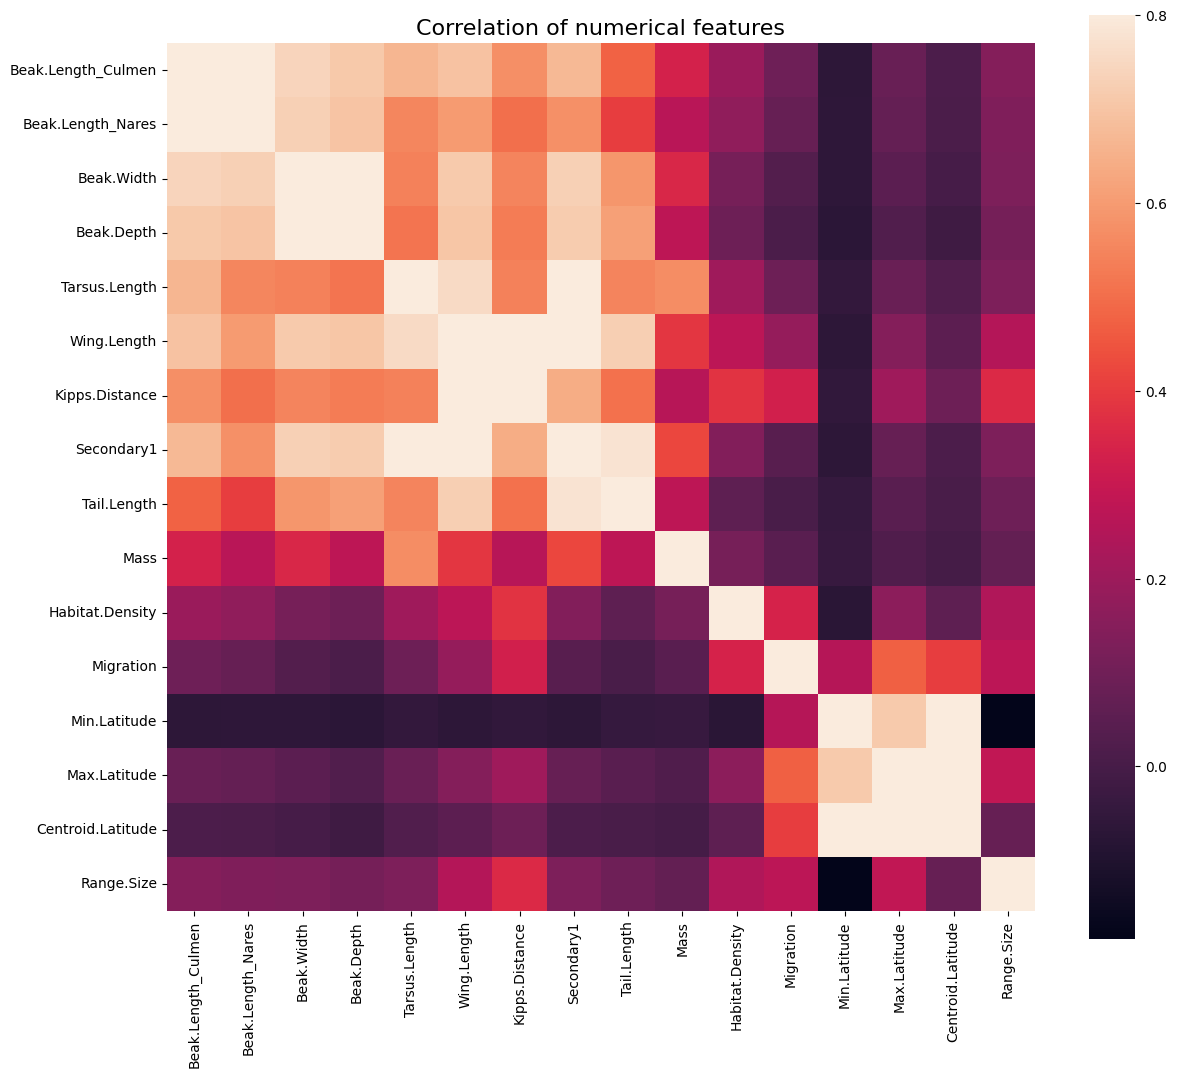

In [ ]:
f , ax = plt.subplots(figsize = (14,12))

plt.title('Correlation of numerical features',y=1,size=16)

sns.heatmap(corr_matrix,square = True,  vmax=0.8)

When the number of variable is not too high, we can consider plotting the heatmap with the correlation value

<Axes: >

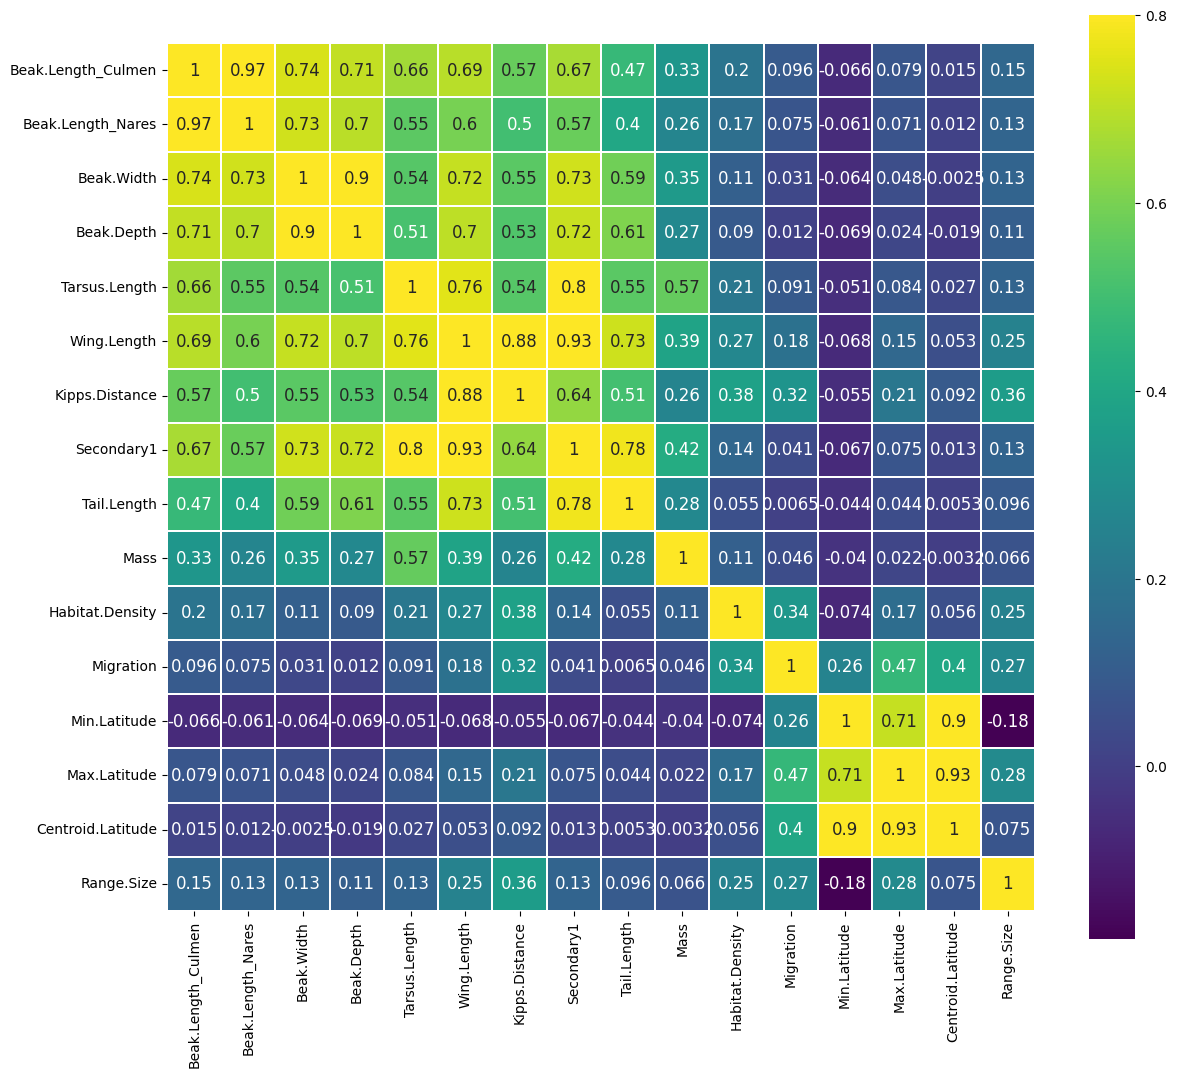

In [ ]:
f , ax = plt.subplots(figsize = (14,12))

sns.heatmap(corr_matrix, vmax=.8, linewidths=0.01,square=True,annot=True,cmap='viridis',
            linecolor="white",annot_kws = {'size':12})

1. What attribute of the data are highly correlated to one another ?
2. What effect can have highly correlated attributes on machine learning analysis ?
3. What would you do about it ?

## Scatterplot of variable

You can investigate the relationship between individuable attributes in more details with scatterplot. Use the cell below and select the attributes you want to investigate

In [ ]:
#attributes = ['Mass']
#pt = scatter_matrix(df[attributes], figsize=(10,8))

How can you explain the relationship between the different longitude variables?

\## Combining attributes
Here, we are not talking about combination produced by methods such as PCA (which have a clear tendency to reduce the meaning of the attribute by producing non-linear combination of attributes).

However, here are some ideas for this dataset : for a given bird (an instance), Kipps.distance and Secondary1 are roughly complementary measure that add up to wing length. A more interesting data here would be the ratio of the wing length these two values correspond to.

These attributes are easy to compute. Let's add them to the dataset :

In [ ]:
df['kipps_on_winglength'] = df['Kipps.Distance']/df['Wing.Length']
df['Beak.nares_to_culmen'] = df['Beak.Length_Nares']/df['Beak.Length_Culmen']
df['Beak.width_to_lculmen'] = df['Beak.Width']/df['Beak.Length_Culmen']
df['Beak.depth_to_lculmen'] = df['Beak.Depth']/df['Beak.Length_Culmen']

<ipython-input-109-057db28b6f9e>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['kipps_on_winglength'] = df['Kipps.Distance']/df['Wing.Length']
<ipython-input-109-057db28b6f9e>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Beak.nares_to_culmen'] = df['Beak.Length_Nares']/df['Beak.Length_Culmen']
<ipython-input-109-057db28b6f9e>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in

In [ ]:
df

,Species3,Beak.Length_Culmen,Beak.Length_Nares,Beak.Width,Beak.Depth,Tarsus.Length,Wing.Length,Kipps.Distance,Secondary1,Tail.Length,...,Primary.Lifestyle,Min.Latitude,Max.Latitude,Centroid.Latitude,Centroid.Longitude,Range.Size,kipps_on_winglength,Beak.nares_to_culmen,Beak.width_to_lculmen,Beak.depth_to_lculmen
0,Accipiter albogularis,27.7,17.8,10.6,14.7,62.0,235.2,81.8,159.5,169.0,...,Insessorial,-11.73,-4.02,-8.15,East,37461.21,0.347789,0.642599,0.382671,0.530686
1,Accipiter badius,20.6,12.1,8.8,11.6,43.0,186.7,62.5,127.4,140.6,...,Insessorial,-29.47,46.39,8.23,Greenwich,22374973.00,0.334762,0.587379,0.427184,0.563107
3,Accipiter brachyurus,22.5,14.0,8.9,11.9,61.2,202.2,64.1,138.1,140.8,...,Insessorial,-6.31,-4.08,-5.45,East,35580.71,0.317013,0.622222,0.395556,0.528889
4,Accipiter brevipes,21.1,12.1,8.7,11.1,46.4,217.6,87.8,129.9,153.5,...,Generalist,31.19,55.86,45.24,Greenwich,2936751.80,0.403493,0.573460,0.412322,0.526066
5,Accipiter butleri,20.0,11.9,6.6,12.0,48.7,166.0,42.9,123.1,127.0,...,Insessorial,7.87,9.26,8.42,East,327.84,0.258434,0.595000,0.330000,0.600000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9988,Trogon personatus,18.9,11.7,8.5,8.9,14.3,125.7,46.9,78.3,157.8,...,Insessorial,-20.40,11.16,-2.92,West,745904.62,0.373111,0.619048,0.449735,0.470899
9989,Trogon rufus,19.9,11.7,8.9,9.8,13.1,113.1,42.8,70.3,130.9,...,Insessorial,-29.64,16.03,-5.73,West,6666233.02,0.378426,0.587940,0.447236,0.492462
9990,Trogon surrucura,19.5,11.8,9.3,9.9,15.3,133.2,51.2,82.0,132.7,...,Insessorial,-31.18,-10.87,-22.48,West,1550766.21,0.384384,0.605128,0.476923,0.507692
9991,Trogon violaceus,19.3,11.6,9.8,8.9,11.5,115.1,42.5,72.6,117.4,...,Insessorial,-15.61,10.84,-3.51,West,5916744.71,0.369244,0.601036,0.507772,0.461140


We can see if we added some information by looking at the correlation matrix :

<Axes: >

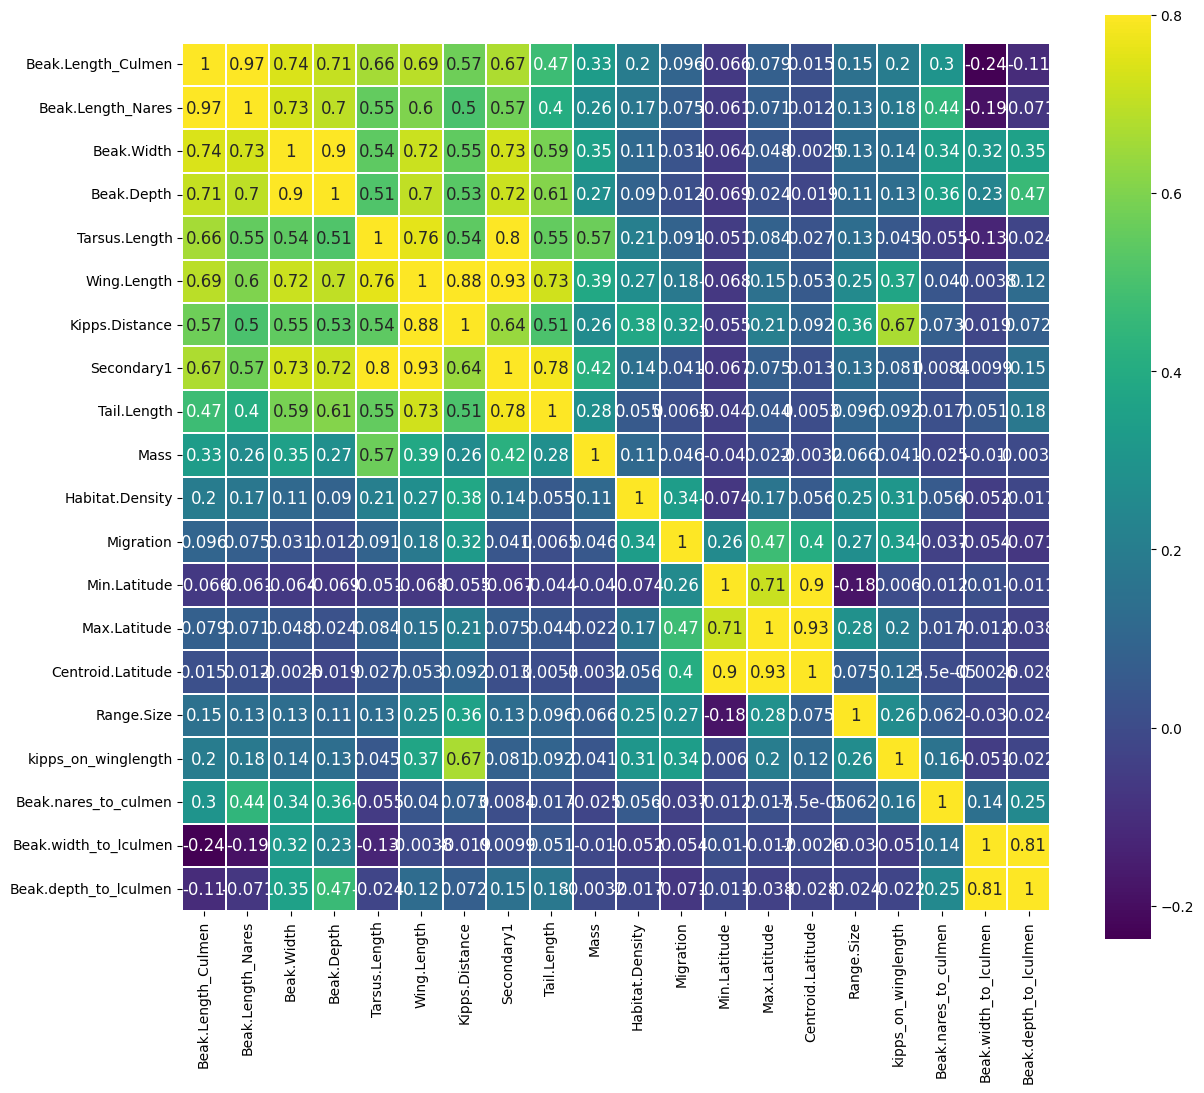

In [ ]:
corr_matrix = df.corr(numeric_only=True)
f , ax = plt.subplots(figsize = (14,12))

sns.heatmap(corr_matrix, vmax=.8, linewidths=0.01,square=True,annot=True,cmap='viridis',
            linecolor="white",annot_kws = {'size':12})

### Question
What is the relationship of this new attribute with the other attributes ?

## Categorical variables

Let's examine the categorical variables in our dataset.

In [ ]:
categorical_features = df.select_dtypes(include=[np.object_])

categorical_features.columns

Index(['Species3', 'Habitat', 'Trophic.Level', 'Trophic.Niche',
       'Primary.Lifestyle'],
      dtype='object')

First, let's take a look at each of the category in our "lifestyle" categories

In [ ]:
df['Habitat'].value_counts()

,count
Habitat,
Forest,5544
Shrubland,1265
Woodland,868
Grassland,745
Wetland,615
Marine,254
Rock,119
Coastal,107
Human Modified,105


In [ ]:
df['Trophic.Level'].value_counts()

,count
Trophic.Level,
Carnivore,5432
Herbivore,2743
Omnivore,1592
Scavenger,20


In [ ]:
df['Trophic.Niche'].value_counts()

,count
Trophic.Niche,
Invertivore,4674
Omnivore,1698
Frugivore,1024
Aquatic predator,743
Granivore,647
Nectarivore,504
Vertivore,300
Herbivore terrestrial,93
Herbivore aquatic,82


In [ ]:
df['Primary.Lifestyle'].value_counts()

,count
Primary.Lifestyle,
Insessorial,5721
Terrestrial,2177
Generalist,865
Aerial,768
Aquatic,256


1. Did you notice something about the Habitat category? What would you do about it?
2. What attributes do you think may influence heavily the other ?
3. Are the categories balanced ?

### Correcting attributes

In [ ]:
df['Habitat'] = df['Habitat'].replace('Shrubland ','Shrubland')

<ipython-input-117-979db36832b9>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Habitat'] = df['Habitat'].replace('Shrubland ','Shrubland')


## Interaction between categorical variables

One way to look at interaction between categories is to generate a contingency table.

In [ ]:

contingency_table = pd.crosstab(df['Trophic.Niche'], df['Trophic.Level'])
contingency_table

Trophic.Level,Carnivore,Herbivore,Omnivore,Scavenger
Trophic.Niche,,,,
Aquatic predator,719,0,24,0
Frugivore,0,866,158,0
Granivore,0,591,56,0
Herbivore aquatic,0,67,15,0
Herbivore terrestrial,0,92,1,0
Invertivore,4254,0,420,0
Nectarivore,0,438,66,0
Omnivore,159,689,850,0
Scavenger,0,0,2,20


1. What would you say about Trophic.level and Trophic.niche as variable
2. What to do about it ?

## Interaction between variables

We can also look at the interaction of our categorical variables on our numerical variable. First, we are interested in predicting the mass, so we can see what relationship they have with mass.
Let's look at the summary statistics.

In [ ]:
df.groupby('Primary.Lifestyle')['Mass'].describe()

,count,mean,std,min,25%,50%,75%,max
Primary.Lifestyle,,,,,,,,
Aerial,768.0,184.514062,518.441345,1.9,5.275,14.6,83.725,4729.3
Aquatic,256.0,1719.383594,2829.729178,84.0,474.100,824.5,1931.550,33569.3
Generalist,865.0,235.702428,582.255370,3.1,18.100,35.3,130.000,7757.0
Insessorial,5721.0,96.723300,254.142628,2.7,12.800,27.2,72.000,5175.3
Terrestrial,2177.0,585.198300,3178.591601,7.0,28.900,76.0,320.500,111000.0


1. Would you say mass is independant from the lifestyle and the trophic niche of the birds ?

It is important to understand the structure of data and how attributes relate to each other before preparing the data for machine learning analysis, since it will impact any of the decision you take to create good models.

Here we used mainly visualization methods and summary statistics to get a sense of how the data are dependant from each other. In practice, it would be more rigorous to use statistical test to know whether or not to reject or accept our different hypothesis.


# Preparing the data

## Removing redundant data

We saw from our analysis that some of our attributes where essentially redundant and carrying mistly the same information.
This can cause issue latter on.
First, keeping redundant attribute needlesly increase the number of parameter your model have to consider.
Second, having two colinear variable might make it  difficult to determine the independent effect of each variable on the target variable.
It may have an impact on the ability of your model to perform its task well and to generalize.

Removing highly correlated variables is one way to remove the redundancy. One more elaborate way would be to perform dimensionality reduction methods on the source data.
However, this come at the tradeoff of reducing intepretabilty in another way.

Drop the columns you identified as being redundant.

In [ ]:
df_nonredundant = df.drop(columns=['Beak.Length_Nares', 'Beak.Width', 'Beak.Depth', 'Kipps.Distance', 'Secondary1',
                                   'Min.Latitude', 'Max.Latitude','Trophic.Level', ])
df_nonredundant = df_nonredundant.reset_index(drop=True)
df_nonredundant

,Species3,Beak.Length_Culmen,Tarsus.Length,Wing.Length,Tail.Length,Mass,Habitat,Habitat.Density,Migration,Trophic.Niche,Primary.Lifestyle,Centroid.Latitude,Centroid.Longitude,Range.Size,kipps_on_winglength,Beak.nares_to_culmen,Beak.width_to_lculmen,Beak.depth_to_lculmen
0,Accipiter albogularis,27.7,62.0,235.2,169.0,248.8,Forest,1.0,2.0,Vertivore,Insessorial,-8.15,East,37461.21,0.347789,0.642599,0.382671,0.530686
1,Accipiter badius,20.6,43.0,186.7,140.6,131.2,Shrubland,2.0,3.0,Vertivore,Insessorial,8.23,Greenwich,22374973.00,0.334762,0.587379,0.427184,0.563107
2,Accipiter brachyurus,22.5,61.2,202.2,140.8,142.0,Forest,1.0,2.0,Vertivore,Insessorial,-5.45,East,35580.71,0.317013,0.622222,0.395556,0.528889
3,Accipiter brevipes,21.1,46.4,217.6,153.5,186.5,Forest,1.0,3.0,Vertivore,Generalist,45.24,Greenwich,2936751.80,0.403493,0.573460,0.412322,0.526066
4,Accipiter butleri,20.0,48.7,166.0,127.0,122.0,Forest,1.0,1.0,Vertivore,Insessorial,8.42,East,327.84,0.258434,0.595000,0.330000,0.600000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9782,Trogon personatus,18.9,14.3,125.7,157.8,63.4,Forest,1.0,1.0,Omnivore,Insessorial,-2.92,West,745904.62,0.373111,0.619048,0.449735,0.470899
9783,Trogon rufus,19.9,13.1,113.1,130.9,53.8,Forest,1.0,1.0,Omnivore,Insessorial,-5.73,West,6666233.02,0.378426,0.587940,0.447236,0.492462
9784,Trogon surrucura,19.5,15.3,133.2,132.7,73.3,Forest,1.0,1.0,Invertivore,Insessorial,-22.48,West,1550766.21,0.384384,0.605128,0.476923,0.507692
9785,Trogon violaceus,19.3,11.5,115.1,117.4,46.5,Forest,1.0,1.0,Frugivore,Insessorial,-3.51,West,5916744.71,0.369244,0.601036,0.507772,0.461140


## Creating a test set
It may seem premature to create a test set at this stage but we are going to transform our training data and our testing data, separately ! We don't want anything to "leak" from our testing data in the training data (for instance, normalizing using the whole dataset, e.g. with both training and testing data, will leak information about one set into the other).

### So, let's split our data before going further.

First, let's have a look at a basic way to extract a training set and a test set from the data.

Scikit-learn has built-in functions we can use, as illustrated in the snippet below. You only have to specify the size of the test set (here, 25% of all data). The variable `random_state` is used to set the seed for the RNG (so the experience is reproducible).

In [ ]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(df_nonredundant, test_size=0.25, random_state=42)

You can have a look at the statistics of both subset. You expect them to be similar. Since instances are picked randomly, they should be but this doesn't mean that randomness is enough to prevent sampling bias.

In [ ]:
train_set.describe()

,Beak.Length_Culmen,Tarsus.Length,Wing.Length,Tail.Length,Mass,Habitat.Density,Migration,Centroid.Latitude,Range.Size,kipps_on_winglength,Beak.nares_to_culmen,Beak.width_to_lculmen,Beak.depth_to_lculmen
count,7340.000000,7340.000000,7340.000000,7340.000000,7340.000000,7340.000000,7340.000000,7340.000000,7.340000e+03,7340.000000,7340.000000,7340.000000,7340.000000
mean,26.392916,29.059210,125.970967,87.479986,279.382221,1.756267,1.290327,2.955755,2.800725e+06,0.256552,0.615670,0.275060,0.323202
std,23.818931,25.704416,94.962282,63.742721,1833.079968,0.783479,0.622106,22.422377,7.947881e+06,0.150320,0.112532,0.115200,0.165388
min,4.500000,2.500000,0.100000,0.100000,1.900000,1.000000,1.000000,-71.040000,8.800000e-01,0.000496,0.015970,0.035226,0.040259
25%,14.600000,17.400000,66.400000,50.075000,14.900000,1.000000,1.000000,-9.812500,7.395439e+04,0.152174,0.544118,0.199124,0.225048
50%,19.800000,22.000000,92.200000,68.400000,35.700000,2.000000,1.000000,-0.210000,5.241514e+05,0.210990,0.602273,0.258929,0.277223
75%,28.800000,31.700000,146.800000,100.500000,126.000000,2.000000,1.000000,15.525000,2.549975e+06,0.321046,0.683449,0.338156,0.378057
max,414.200000,475.000000,789.900000,812.800000,111000.000000,3.000000,3.000000,78.430000,1.363044e+08,1.000000,1.255422,1.378182,1.218462


In [ ]:
test_set.describe()

,Beak.Length_Culmen,Tarsus.Length,Wing.Length,Tail.Length,Mass,Habitat.Density,Migration,Centroid.Latitude,Range.Size,kipps_on_winglength,Beak.nares_to_culmen,Beak.width_to_lculmen,Beak.depth_to_lculmen
count,2447.000000,2447.000000,2447.000000,2447.000000,2447.000000,2447.000000,2447.000000,2447.000000,2.447000e+03,2447.000000,2447.000000,2447.000000,2447.000000
mean,26.756355,28.850266,126.156191,86.334205,229.839313,1.752758,1.304046,3.165415,2.798826e+06,0.257298,0.615203,0.271424,0.318551
std,28.032046,23.291490,95.617399,58.149913,689.540284,0.778235,0.631611,22.685788,7.819128e+06,0.151866,0.111805,0.112283,0.159646
min,4.700000,2.500000,0.100000,0.100000,2.000000,1.000000,1.000000,-62.260000,9.700000e-01,0.031288,0.030583,0.025667,0.030801
25%,14.800000,17.600000,67.100000,50.200000,15.400000,1.000000,1.000000,-10.340000,7.757465e+04,0.152319,0.541667,0.196327,0.222911
50%,20.100000,22.100000,91.200000,68.200000,35.500000,2.000000,1.000000,-0.610000,5.369921e+05,0.211561,0.598945,0.254980,0.276119
75%,28.000000,31.450000,145.650000,101.150000,122.000000,2.000000,1.000000,16.270000,2.658355e+06,0.319888,0.684651,0.331412,0.372781
max,414.000000,301.000000,711.400000,698.900000,9512.100000,3.000000,3.000000,74.490000,1.224599e+08,1.000000,1.038911,1.020513,1.155642


### Stratified split

We know one of our categorical variables, `Trophic.niche` has categories with few members. If we think this variable is important for the question we want to answer, we may want both our training and test dataset to have a similar representation of each class.

Use Scikit-learn to perform a stratified split of the data
> Stratified ShuffleSplit cross-validator.
> Provides train/test indices to split data in train/test sets.
> This cross-validation object is a merge of StratifiedKFold and ShuffleSplit, which returns stratified randomized folds. **The folds are made by preserving the percentage of samples for each class.**


In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit
split = StratifiedShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
for train_index, test_index in split.split(df_nonredundant, df_nonredundant['Trophic.Niche']):

    strat_train_set = df_nonredundant.loc[train_index]
    strat_test_set = df_nonredundant.loc[test_index]

You can check the proportion of new training and testing set for the selected category.

In [ ]:
df_nonredundant['Trophic.Niche'].value_counts() / len(df_nonredundant)

,count
Trophic.Niche,
Invertivore,0.477572
Omnivore,0.173495
Frugivore,0.104629
Aquatic predator,0.075917
Granivore,0.066108
Nectarivore,0.051497
Vertivore,0.030653
Herbivore terrestrial,0.009502
Herbivore aquatic,0.008378


In [ ]:
strat_train_set['Trophic.Niche'].value_counts() / len(strat_train_set)

,count
Trophic.Niche,
Invertivore,0.477520
Omnivore,0.173433
Frugivore,0.104632
Aquatic predator,0.075886
Granivore,0.066076
Nectarivore,0.051499
Vertivore,0.030654
Herbivore terrestrial,0.009537
Herbivore aquatic,0.008447


In [ ]:
strat_test_set['Trophic.Niche'].value_counts() / len(strat_test_set)

,count
Trophic.Niche,
Invertivore,0.477728
Omnivore,0.173682
Frugivore,0.104618
Aquatic predator,0.076011
Granivore,0.066204
Nectarivore,0.051492
Vertivore,0.030650
Herbivore terrestrial,0.009399
Herbivore aquatic,0.008173


Now, we will make a copy of our (stratified) training data : we are going to build a set of inputs only and a set of outputs (targets) only

In [ ]:
X_train = strat_train_set.drop('Mass', axis=1) # remove the target
Y_train = strat_train_set['Mass'].copy()

Let's continue with data preparation on the training set.

**Warning** : We will need to do the same on the test set afterward.

### Feature normalization
We already noted that the attributes of the dataset have very different scales. However, we want each attribute to contribute equaly. For that, we can normalize the features.

We can use **scaling** (i.e. put all the values in range min;max) but at the cost of losing the original data distribution (outliers are in the mix).

The second option is **standardization**. In this case, the variance has unit value, the mean is 0 and the distribution of the data is preserved.

*Note :* It is often not necessary to normalize the targets (they don't weight during the training process). We are not going to normalize the one-hots either (this can be discussed...)

[More about scaling and standardization](http://www.faqs.org/faqs/ai-faq/neural-nets/part2/section-16.html)

Let's standardize the training data:

In [ ]:
from sklearn.preprocessing import StandardScaler
X_train_num = X_train.select_dtypes(include=np.number)
X_train_np = X_train_num.values # returns X_train as a numpy array
scaler = StandardScaler()
X_train_std = pd.DataFrame(scaler.fit_transform(X_train_np),
                          columns=X_train_num.columns, index=X_train_num.index)
X_train_std.head()

,Beak.Length_Culmen,Tarsus.Length,Wing.Length,Tail.Length,Habitat.Density,Migration,Centroid.Latitude,Range.Size,kipps_on_winglength,Beak.nares_to_culmen,Beak.width_to_lculmen,Beak.depth_to_lculmen
9609,1.116793,1.622550,2.934715,2.103910,-0.963478,-0.47033,-0.271226,0.244019,-0.369182,-0.339517,0.531896,0.868472
3013,-0.558080,-0.277336,-0.789305,-0.395192,0.316278,-0.47033,-1.372262,-0.330488,-0.945330,-0.277073,-0.435044,-0.593989
6442,0.093260,0.261611,0.186361,2.748944,-0.963478,-0.47033,-0.226862,-0.342423,-0.381577,0.189669,0.167796,0.214885
7851,-0.367937,-0.444061,-0.529268,-0.147226,0.316278,-0.47033,0.735704,-0.350268,-0.585747,-0.144822,0.996550,-0.435438
9786,-0.044290,-0.575889,0.217015,1.160669,-0.963478,-0.47033,-0.354129,0.666554,0.594635,-0.176903,1.093919,0.871301


We now have standardized value for our numerical data. Let's deal with our categorical data now.

### Dealing with categorical attributes
We must transform the attribute `Habitat` , `Primary.Lifestyle` and  `Trophic.Niche` into something a ML algorithm will be able to process.

We saw before that Habitat.Density and Migration are essentially categorical variables that were transformed into a numeric value.
We could imagine doing this with the others. For example for `Habitat` having Aerial become 1, Aquatic become 2, Generalist become 3...
But it would look like to the model that Aquatic is closer to Aquatic than from Generalist, which is odd.

So instead of using single values for each categories, we can use a one-hot vector:
00001, 00010, 00100, etc.

In [ ]:
habitat_cat_1hot = pd.get_dummies(X_train['Habitat'])
habitat_cat_1hot.head()

,Coastal,Desert,Forest,Grassland,Human Modified,Marine,Riverine,Rock,Shrubland,Wetland,Woodland
9609,False,False,False,False,False,False,False,False,False,True,False
3013,False,False,False,False,False,False,False,False,False,False,True
6442,False,False,True,False,False,False,False,False,False,False,False
7851,False,False,True,False,False,False,False,False,False,False,False
9786,False,False,True,False,False,False,False,False,False,False,False


Do this for the other categorical attributs

In [ ]:
lifestlye_cat_1hot = pd.get_dummies(X_train['Primary.Lifestyle'])


In [ ]:
niche_cat_1hot = pd.get_dummies(X_train['Trophic.Niche'])


In [ ]:
centlong_cat_1hot = pd.get_dummies(X_train['Centroid.Longitude'])

Now drop the attribute you just transformed (we no longer need it, and we can't normalize it anyway) :

In [ ]:
X_train.drop(['Habitat'], axis=1, inplace=True)
X_train.drop(['Primary.Lifestyle'], axis=1, inplace=True)
X_train.drop(['Trophic.Niche'], axis=1, inplace=True)
X_train.drop(['Centroid.Longitude'], axis=1, inplace=True)


## Stiching back the data together

Before going further, let's concatenate the standardized training set with the one-hots we created earlier :

In [ ]:
X_train_std = pd.concat([X_train_std, habitat_cat_1hot, lifestlye_cat_1hot, niche_cat_1hot,  centlong_cat_1hot], axis=1)
X_train_std.head()

,Beak.Length_Culmen,Tarsus.Length,Wing.Length,Tail.Length,Habitat.Density,Migration,Centroid.Latitude,Range.Size,kipps_on_winglength,Beak.nares_to_culmen,...,Herbivore aquatic,Herbivore terrestrial,Invertivore,Nectarivore,Omnivore,Scavenger,Vertivore,West,Greenwich,East
9609,1.116793,1.622550,2.934715,2.103910,-0.963478,-0.47033,-0.271226,0.244019,-0.369182,-0.339517,...,False,False,False,False,False,False,False,False,True,False
3013,-0.558080,-0.277336,-0.789305,-0.395192,0.316278,-0.47033,-1.372262,-0.330488,-0.945330,-0.277073,...,False,False,True,False,False,False,False,False,True,False
6442,0.093260,0.261611,0.186361,2.748944,-0.963478,-0.47033,-0.226862,-0.342423,-0.381577,0.189669,...,False,False,False,False,False,False,False,False,False,True
7851,-0.367937,-0.444061,-0.529268,-0.147226,0.316278,-0.47033,0.735704,-0.350268,-0.585747,-0.144822,...,False,False,True,False,False,False,False,True,False,False
9786,-0.044290,-0.575889,0.217015,1.160669,-0.963478,-0.47033,-0.354129,0.666554,0.594635,-0.176903,...,False,False,False,False,False,False,False,True,False,False


In [ ]:
X_train_std.columns

Index(['Beak.Length_Culmen', 'Tarsus.Length', 'Wing.Length', 'Tail.Length',
       'Habitat.Density', 'Migration', 'Centroid.Latitude', 'Range.Size',
       'kipps_on_winglength', 'Beak.nares_to_culmen', 'Beak.width_to_lculmen',
       'Beak.depth_to_lculmen', 'Coastal', 'Desert', 'Forest', 'Grassland',
       'Human Modified', 'Marine', 'Riverine', 'Rock', 'Shrubland', 'Wetland',
       'Woodland', 'Aerial', 'Aquatic', 'Generalist', 'Insessorial',
       'Terrestrial', 'Aquatic predator', 'Frugivore', 'Granivore',
       'Herbivore aquatic', 'Herbivore terrestrial', 'Invertivore',
       'Nectarivore', 'Omnivore', 'Scavenger', 'Vertivore', 'West',
       'Greenwich', 'East'],
      dtype='object')

# Selecting and training a model
Now that we have nice and clean data (ahem...), let's try to learn something from them.

*Note that none of the models we will use for regression will give satisfying results. The point here is more to see how to use ML models from Scikit-Learn.*

We will use `X_train_std` as inputs and `Y_train` as target outputs.

In [ ]:
X_train_std.head()

,Beak.Length_Culmen,Tarsus.Length,Wing.Length,Tail.Length,Habitat.Density,Migration,Centroid.Latitude,Range.Size,kipps_on_winglength,Beak.nares_to_culmen,...,Herbivore aquatic,Herbivore terrestrial,Invertivore,Nectarivore,Omnivore,Scavenger,Vertivore,West,Greenwich,East
9609,1.116793,1.622550,2.934715,2.103910,-0.963478,-0.47033,-0.271226,0.244019,-0.369182,-0.339517,...,False,False,False,False,False,False,False,False,True,False
3013,-0.558080,-0.277336,-0.789305,-0.395192,0.316278,-0.47033,-1.372262,-0.330488,-0.945330,-0.277073,...,False,False,True,False,False,False,False,False,True,False
6442,0.093260,0.261611,0.186361,2.748944,-0.963478,-0.47033,-0.226862,-0.342423,-0.381577,0.189669,...,False,False,False,False,False,False,False,False,False,True
7851,-0.367937,-0.444061,-0.529268,-0.147226,0.316278,-0.47033,0.735704,-0.350268,-0.585747,-0.144822,...,False,False,True,False,False,False,False,True,False,False
9786,-0.044290,-0.575889,0.217015,1.160669,-0.963478,-0.47033,-0.354129,0.666554,0.594635,-0.176903,...,False,False,False,False,False,False,False,True,False,False


In [ ]:
Y_train.head()

,Mass
9609,1942.8
3013,10.5
6442,248.0
7851,17.2
9786,89.7


## Preparing the testing data
We need to process our testing data the same way we did with the training data.
(and I realize how wrong I was not to write functions...)

In [ ]:
# 1. Split intputs and outputs
X_test = strat_test_set.drop('Mass', axis=1) # remove the target
Y_test = strat_test_set['Mass'].copy()

In [ ]:
X_test

,Species3,Beak.Length_Culmen,Tarsus.Length,Wing.Length,Tail.Length,Habitat,Habitat.Density,Migration,Trophic.Niche,Primary.Lifestyle,Centroid.Latitude,Centroid.Longitude,Range.Size,kipps_on_winglength,Beak.nares_to_culmen,Beak.width_to_lculmen,Beak.depth_to_lculmen
9392,Tanygnathus megalorynchos,49.4,22.2,236.2,147.8,Forest,1.0,1.0,Frugivore,Insessorial,-4.07,East,96725.71,0.465707,0.912955,0.540486,1.002024
5599,Basileuterus belli,12.3,21.2,59.7,59.7,Forest,1.0,1.0,Invertivore,Insessorial,18.67,West,334156.38,0.149079,0.593496,0.292683,0.300813
2937,Apalis ruddi,10.4,20.3,46.0,46.2,Woodland,1.0,1.0,Invertivore,Insessorial,-23.94,Greenwich,167381.68,0.084783,0.701923,0.326923,0.288462
520,Amazilia brevirostris,19.6,5.1,48.8,28.5,Forest,1.0,1.0,Nectarivore,Aerial,6.43,West,584285.40,0.620902,0.775510,0.107143,0.091837
5025,Cercomela familiaris,18.1,24.1,82.9,60.4,Shrubland,2.0,1.0,Invertivore,Insessorial,-10.67,Greenwich,7293437.67,0.201448,0.535912,0.182320,0.198895
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
243,Aix galericulata,33.0,34.8,222.2,94.6,Forest,3.0,3.0,Herbivore aquatic,Generalist,45.58,East,1904941.91,0.500000,0.633333,0.409091,0.321212
5896,Batis fratrum,16.0,19.2,60.0,35.3,Forest,1.0,1.0,Invertivore,Insessorial,-21.12,Greenwich,296075.25,0.115000,0.506250,0.331250,0.237500
3071,Aphelocoma unicolor,35.0,42.6,168.9,153.7,Forest,1.0,1.0,Omnivore,Insessorial,16.23,West,149103.75,0.185317,0.565714,0.302857,0.311429
784,Phaethornis philippii,36.0,4.5,56.8,61.4,Forest,1.0,1.0,Nectarivore,Aerial,-7.46,West,1596505.84,0.665493,0.813889,0.080556,0.072222


In [ ]:
# 2. Standardize features
X_test_num = X_test.select_dtypes(include=np.number)
X_test_np = X_test_num.values # returns X_train as a numpy array
scaler = StandardScaler()
X_test_std = pd.DataFrame(scaler.fit_transform(X_test_np),
                          columns=X_test_num.columns, index=X_test_num.index)
X_test_std.head()

,Beak.Length_Culmen,Tarsus.Length,Wing.Length,Tail.Length,Habitat.Density,Migration,Centroid.Latitude,Range.Size,kipps_on_winglength,Beak.nares_to_culmen,Beak.width_to_lculmen,Beak.depth_to_lculmen
9392,0.873944,-0.290082,1.126344,0.922272,-0.973033,-0.470733,-0.289095,-0.329883,1.389953,2.624645,2.404738,4.137182
5599,-0.576810,-0.333575,-0.700175,-0.446101,-0.973033,-0.470733,0.700186,-0.301931,-0.720163,-0.208045,0.171182,-0.141109
2937,-0.651108,-0.372719,-0.841951,-0.655784,-0.973033,-0.470733,-1.153519,-0.321565,-1.148653,0.753393,0.479804,-0.216469
520,-0.291352,-1.033819,-0.812975,-0.930701,-0.973033,-0.470733,0.167697,-0.272483,2.424221,1.405899,-1.501171,-1.416133
5025,-0.350008,-0.207444,-0.460089,-0.435229,0.302281,-0.470733,-0.576221,0.517381,-0.371160,-0.718653,-0.823563,-0.762940


In [ ]:
# 3. Transform categories into one-hot
habitat_cat_1hot_test = pd.get_dummies(X_test['Habitat'])
lifestyle_cat_1hot_test = pd.get_dummies(X_test['Primary.Lifestyle'])
niche_cat_1hot_test = pd.get_dummies(X_test['Trophic.Niche'])
centlong_cat_1hot_test = pd.get_dummies(X_test['Centroid.Longitude'])

X_test.drop(['Habitat'], axis=1, inplace=True)
X_test.drop(['Primary.Lifestyle'], axis=1, inplace=True)
X_test.drop(['Trophic.Niche'], axis=1, inplace=True)
X_test.drop(['Centroid.Longitude'], axis=1, inplace=True)


In [ ]:
X_test_std = pd.concat([X_test_std, habitat_cat_1hot_test, lifestyle_cat_1hot_test, niche_cat_1hot_test, centlong_cat_1hot_test], axis=1)

In [ ]:
X_test_std.columns

Index(['Beak.Length_Culmen', 'Tarsus.Length', 'Wing.Length', 'Tail.Length',
       'Habitat.Density', 'Migration', 'Centroid.Latitude', 'Range.Size',
       'kipps_on_winglength', 'Beak.nares_to_culmen', 'Beak.width_to_lculmen',
       'Beak.depth_to_lculmen', 'Coastal', 'Desert', 'Forest', 'Grassland',
       'Human Modified', 'Marine', 'Riverine', 'Rock', 'Shrubland', 'Wetland',
       'Woodland', 'Aerial', 'Aquatic', 'Generalist', 'Insessorial',
       'Terrestrial', 'Aquatic predator', 'Frugivore', 'Granivore',
       'Herbivore aquatic', 'Herbivore terrestrial', 'Invertivore',
       'Nectarivore', 'Omnivore', 'Scavenger', 'Vertivore', 'West',
       'Greenwich', 'East'],
      dtype='object')

## Linear regression
Let's start gently :-)

In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train_std, Y_train)

LinearRegression()

In [ ]:
X_test_std.columns

Index(['Beak.Length_Culmen', 'Tarsus.Length', 'Wing.Length', 'Tail.Length',
       'Habitat.Density', 'Migration', 'Centroid.Latitude', 'Range.Size',
       'kipps_on_winglength', 'Beak.nares_to_culmen', 'Beak.width_to_lculmen',
       'Beak.depth_to_lculmen', 'Coastal', 'Desert', 'Forest', 'Grassland',
       'Human Modified', 'Marine', 'Riverine', 'Rock', 'Shrubland', 'Wetland',
       'Woodland', 'Aerial', 'Aquatic', 'Generalist', 'Insessorial',
       'Terrestrial', 'Aquatic predator', 'Frugivore', 'Granivore',
       'Herbivore aquatic', 'Herbivore terrestrial', 'Invertivore',
       'Nectarivore', 'Omnivore', 'Scavenger', 'Vertivore', 'West',
       'Greenwich', 'East'],
      dtype='object')

In [ ]:
from sklearn.metrics import mean_squared_error

predictions = lr.predict(X_test_std)
lr_mse = mean_squared_error(Y_test, predictions)
np.sqrt(lr_mse)

858.5735742212679

### Questions
1. Look back at the percentiles computed earlier. What can you tell about `Mass` ?
2. What about the error you just computed ?

Let's try with a more complex model ?

## Decision tree
Decision trees can capture non-linear relationships in the data. Let's try:

In [ ]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = DecisionTreeRegressor()
tree_reg.fit(X_train_std, Y_train)

tr_pred = tree_reg.predict(X_test_std)
tr_mse = mean_squared_error(Y_test, tr_pred)
np.sqrt(tr_mse)

474.68889374398736

### Question
Is that any better ?

[//]: # (How, it's actually worse !)

Let's look at the importance of each feature in the decision tree

In [ ]:
#Importance of each feature
[f"{x:30}{y:.2f}" for y,x in sorted(zip(tree_reg.feature_importances_,X_test_std.columns),reverse=True)]

['kipps_on_winglength           0.59',
 'Shrubland                     0.19',
 'Wing.Length                   0.12',
 'Centroid.Latitude             0.05',
 'Forest                        0.01',
 'Tarsus.Length                 0.01',
 'Aquatic                       0.01',
 'Beak.Length_Culmen            0.01',
 'Beak.depth_to_lculmen         0.00',
 'Beak.nares_to_culmen          0.00',
 'Beak.width_to_lculmen         0.00',
 'Vertivore                     0.00',
 'Range.Size                    0.00',
 'Wetland                       0.00',
 'Tail.Length                   0.00',
 'Herbivore terrestrial         0.00',
 'Omnivore                      0.00',
 'Greenwich                     0.00',
 'Herbivore aquatic             0.00',
 'Aerial                        0.00',
 'East                          0.00',
 'Grassland                     0.00',
 'Habitat.Density               0.00',
 'Frugivore                     0.00',
 'Migration                     0.00',
 'Rock                   

## Support Vector Machine

In [ ]:
from sklearn.svm import SVR

svm_reg = SVR(gamma='auto')
svm_reg.fit(X_train_std, Y_train)

svr_pred = svm_reg.predict(X_test_std)
svr_mse = mean_squared_error(Y_test, svr_pred)
np.sqrt(svr_mse)

1127.663753450332

### Question
How about this model ?

[//]: # (It was slow to compute, and the result is worse than the two previous models !)

## Other regression models
Have a look at [Scikit-Learn online documentation](https://scikit-learn.org/stable/supervised_learning.html) and choose a few regression models (random forest, ensemble methods or multi-layer perceptron are a good start).

The results obtained by the different models we tried were not thrilling. It can be caused by several things :
* the features are not informative enough
* the models are not complex enough
* data were badly preprocessed
* ... the question was not that great to begin with for this dataset.

Now let's try another task : predicting the trophic niche of a bird (what do they eat) given physiology data. We may have better chance with this one. But we need to reprocess the data.
Note : Normally we would need to redo some feature exploration to make sure our data fits to the question.

In [ ]:
def process_data(dataset):
    # 1. Split intputs and outputs
    X_set = dataset.drop('Trophic.Niche', axis=1) # remove the target
    Y_set = dataset['Trophic.Niche'].copy()
    #2. Standardize
    X_set_num = X_set.select_dtypes(include=np.number)
    X_set_np = X_set_num.values # returns X_train as a numpy array
    scaler = StandardScaler()
    X_set_std = pd.DataFrame(scaler.fit_transform(X_set_np),
                              columns=X_set_num.columns, index=X_set_num.index)
    #3. Encode categorical variables
    habitat_cat_1hot = pd.get_dummies(X_set['Habitat'])
    lifestyle_cat_1hot = pd.get_dummies(X_set['Primary.Lifestyle'])
    centlong_cat_1hot = pd.get_dummies(X_set['Centroid.Longitude'])
    X_set.drop(['Habitat'], axis=1, inplace=True)
    X_set.drop(['Primary.Lifestyle'], axis=1, inplace=True)
    X_set.drop(['Centroid.Longitude'], axis=1, inplace=True)
    #4. Strich the data back together
    X_set_std = pd.concat([X_set_std, habitat_cat_1hot, lifestyle_cat_1hot, centlong_cat_1hot], axis=1)
    return X_set_std, Y_set

Let's use the same split as before, since it is well adapted to the task at hand

In [ ]:
X_train_niche, Y_train_niche = process_data(strat_train_set)
X_test_niche, Y_test_niche = process_data(strat_test_set)

## Classifier


### Decision tree classifier

In [ ]:
from sklearn.tree import DecisionTreeClassifier # Import Decision Tree Classifier
from sklearn import metrics #Import scikit-learn metrics module for accuracy calculation
# Create Decision Tree classifer object
tree_class = DecisionTreeClassifier(max_depth=4)

# Train Decision Tree Classifer
tree_class = tree_class.fit(X_train_niche,Y_train_niche)

#Predict the response for test dataset
y_pred = tree_class.predict(X_test_niche)

#### Confusion matrix

In [ ]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_pred,Y_test_niche,labels=list(set(Y_test_niche)))
print(list(set(Y_test_niche)))
print(confusion_matrix(y_pred,Y_test_niche,labels=list(set(Y_test_niche))))

['Aquatic predator', 'Herbivore terrestrial', 'Vertivore', 'Omnivore', 'Nectarivore', 'Herbivore aquatic', 'Scavenger', 'Granivore', 'Invertivore', 'Frugivore']
[[  81    0    0   15    0    1    0    0    3    0]
 [   0    0    0    0    0    0    0    0    0    0]
 [   4    1   39    9    0    0    0    0    1   18]
 [  31   18   25  163    7   18    5   30   57   36]
 [   6    0    0    5   89    0    0    0    7    0]
 [   0    0    0    0    0    0    0    0    0    0]
 [   0    0    0    0    0    0    0    0    0    0]
 [   1    2    2   23    1    0    0  107    8   15]
 [  62    0    2  178   28    0    0   17 1065  129]
 [   1    2    7   32    1    1    0    8   28   58]]


### Global accuracy

In [ ]:
print(metrics.classification_report(y_pred,Y_test_niche))

                       precision    recall  f1-score   support

     Aquatic predator       0.44      0.81      0.57       100
            Frugivore       0.23      0.42      0.29       138
            Granivore       0.66      0.67      0.67       159
    Herbivore aquatic       0.00      0.00      0.00         0
Herbivore terrestrial       0.00      0.00      0.00         0
          Invertivore       0.91      0.72      0.80      1481
          Nectarivore       0.71      0.83      0.76       107
             Omnivore       0.38      0.42      0.40       390
            Scavenger       0.00      0.00      0.00         0
            Vertivore       0.52      0.54      0.53        72

             accuracy                           0.65      2447
            macro avg       0.38      0.44      0.40      2447
         weighted avg       0.73      0.65      0.68      2447



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Questions

1. Is the performance of the model good ?
2. Is it good across all class ?
3. Why is it ?
4. What do you think will be the most important feature(s) ?

### Feature importance

In [ ]:
#Importance of each feature
[f"{x:30}{y:.2f}" for y,x in sorted(zip(tree_class.feature_importances_,X_test_niche.columns),reverse=True)]

['Beak.depth_to_lculmen         0.38',
 'Mass                          0.25',
 'Habitat.Density               0.08',
 'Beak.width_to_lculmen         0.08',
 'Tarsus.Length                 0.05',
 'Insessorial                   0.05',
 'Terrestrial                   0.04',
 'Marine                        0.03',
 'kipps_on_winglength           0.02',
 'Tail.Length                   0.01',
 'Woodland                      0.00',
 'Wing.Length                   0.00',
 'Wetland                       0.00',
 'West                          0.00',
 'Shrubland                     0.00',
 'Rock                          0.00',
 'Riverine                      0.00',
 'Range.Size                    0.00',
 'Migration                     0.00',
 'Human Modified                0.00',
 'Greenwich                     0.00',
 'Grassland                     0.00',
 'Generalist                    0.00',
 'Forest                        0.00',
 'East                          0.00',
 'Desert                 

Does the feature importance fit what you thought ?

###  Random forest classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification

clf = RandomForestClassifier(max_depth=10)
clf.fit(X_train_niche, Y_train_niche)
print(clf.predict(X_test_niche))
y_pred = clf.predict(X_test_niche)


['Omnivore' 'Invertivore' 'Invertivore' ... 'Invertivore' 'Nectarivore'
 'Invertivore']


### Confusion matrix

In [ ]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_pred,Y_test_niche,labels=list(set(Y_test_niche)))
print(list(set(y_pred)))
print(confusion_matrix(y_pred,Y_test_niche,labels=list(set(Y_test_niche))))

['Aquatic predator', 'Herbivore terrestrial', 'Vertivore', 'Omnivore', 'Nectarivore', 'Herbivore aquatic', 'Scavenger', 'Granivore', 'Invertivore', 'Frugivore']
[[ 148    0    0   17    0    3    0    0    3    0]
 [   0   11    0    1    0    0    0    1    0    0]
 [   4    1   66    5    0    0    0    0    8    0]
 [   7   11    3  162    7    3    1   16   13   26]
 [   1    0    0   13  108    0    0    0    2    0]
 [   4    0    0    2    0   14    0    0    0    0]
 [   0    0    0    0    0    0    4    0    0    0]
 [   0    0    1   37    1    0    0  121    7    8]
 [  22    0    4  171    9    0    0   19 1130  145]
 [   0    0    1   17    1    0    0    5    6   77]]


### Accuracy

In [ ]:
print(metrics.classification_report(y_pred,Y_test_niche))

                       precision    recall  f1-score   support

     Aquatic predator       0.80      0.87      0.83       171
            Frugivore       0.30      0.72      0.42       107
            Granivore       0.75      0.69      0.72       175
    Herbivore aquatic       0.70      0.70      0.70        20
Herbivore terrestrial       0.48      0.85      0.61        13
          Invertivore       0.97      0.75      0.85      1500
          Nectarivore       0.86      0.87      0.86       124
             Omnivore       0.38      0.65      0.48       249
            Scavenger       0.80      1.00      0.89         4
            Vertivore       0.88      0.79      0.83        84

             accuracy                           0.75      2447
            macro avg       0.69      0.79      0.72      2447
         weighted avg       0.84      0.75      0.78      2447



## Multilayer Perceptron

In [ ]:
from sklearn.neural_network import MLPClassifier

clf = MLPClassifier(solver='lbfgs', alpha=1e-5,
                    hidden_layer_sizes=(55, 5), random_state=1,max_iter=100)
clf.fit(X_train_niche, Y_train_niche)
print(clf.predict(X_test_niche))
y_pred = clf.predict(X_test_niche)


['Frugivore' 'Invertivore' 'Invertivore' ... 'Frugivore' 'Nectarivore'
 'Frugivore']


/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:545: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


### Confusion matrix

In [ ]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_pred,Y_test_niche,labels=list(set(Y_test_niche)))
print(list(set(Y_test_niche)))
print(confusion_matrix(y_pred,Y_test_niche,labels=list(set(Y_test_niche))))

['Aquatic predator', 'Herbivore terrestrial', 'Vertivore', 'Omnivore', 'Nectarivore', 'Herbivore aquatic', 'Scavenger', 'Granivore', 'Invertivore', 'Frugivore']
[[ 160    2    0   16    0    3    0    0    4    0]
 [   0    0    0    0    0    0    0    0    0    0]
 [   0    1   61   10    3    0    0    1   13    0]
 [  11   18    8  186    3    3    4   23   64   22]
 [   0    0    1   12  108    0    0    0    4    0]
 [   8    0    0    3    0   13    0    0    0    0]
 [   1    0    0    0    0    1    1    0    0    0]
 [   0    2    1   40    0    0    0  124    1    6]
 [   6    0    3  111   12    0    0   10 1057   60]
 [   0    0    1   47    0    0    0    4   26  168]]


### Accuracy

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_pred,Y_test_niche))

                       precision    recall  f1-score   support

     Aquatic predator       0.86      0.86      0.86       185
            Frugivore       0.66      0.68      0.67       246
            Granivore       0.77      0.71      0.74       174
    Herbivore aquatic       0.65      0.54      0.59        24
Herbivore terrestrial       0.00      0.00      0.00         0
          Invertivore       0.90      0.84      0.87      1259
          Nectarivore       0.86      0.86      0.86       125
             Omnivore       0.44      0.54      0.49       342
            Scavenger       0.20      0.33      0.25         3
            Vertivore       0.81      0.69      0.74        89

             accuracy                           0.77      2447
            macro avg       0.61      0.61      0.61      2447
         weighted avg       0.79      0.77      0.78      2447



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Questions

What do you think of the performance of all these method? You can look up the hyperparameters and try to improve the prediction. Does it make any difference?

You can try other classifier model to see if you get better results. Look up the classifiers available in sklearn.

# Some conclusions...


We arrived to reasonable but not the most exciting result on this dataset.

It is, however, an interesting dataset to look at to build a ML workflow. Beware that this is not an exhaustive workflow (quite far from it) but rather some directions you can keep in mind to look at data.

* To learn more about feature engineering :
>Feature Engineering for Machine Learning and Data Analytics, 1st ed., Guozhu Dong, Huan Liu, ISBN 9781138744387, 2018.

* A course on [Descriptive Statistics](https://www.edx.org/course/introduction-statistics-descriptive-uc-berkeleyx-stat2-1x) on edX

# ... and going further
The results obtained by the different models we tried were not thrilling. It can be caused by several things :
* the features are not informative enough
* the models are not complex enough
* data were badly preprocessed
* ...

Solutions include using a different model (yet again), selecting the most informative features [feature selection with Scikit-learn](https://scikit-learn.org/stable/supervised_learning.html), obtain / craft better features, use [K-fold cross validation](https://scikit-learn.org/stable/modules/cross_validation.html) to create a better model, find better hyperparameters, ...

Next, we will try more elaborate model with TensorFlow!

# TensorFlow

To train more complicated models, we will use TensorFlow.

TensorFlow is an open-source library for numerical computation, large-scale machine learning, deep learning, and other statistical and predictive analytics workloads. This type of technology makes it faster and easier for developers to implement machine learning models, as it assists the process of acquiring data, serving predictions at scale, and refining future results.

Let's start by importing it

In [ ]:
import tensorflow as tf

For now, we will keep our preprocessed data.

In [ ]:
X_train_niche, Y_train_niche = process_data(strat_train_set)
X_test_niche, Y_test_niche = process_data(strat_test_set)

First, we need to make our data compatible with TensorFlow.
We need to:
- encode our categories as one-hot vector. (Text is not a valid output)
- transform our dataframe into objects compatible with TensorFlow

In [ ]:
# A utility method to create a tf.data dataset from a Pandas Dataframe
from sklearn.preprocessing import LabelEncoder


def datatarget_to_dataset(dataframe, target, batch=1):
    dataframe = dataframe.copy()
    #Encode the categories as numbers
    encoder = LabelEncoder()
    target = encoder.fit_transform(target)
    #Encode the categories as one-hot vectors
    target = tf.keras.utils.to_categorical(target, 10)
    #Slice the dataframe into object compatible with Tensforflow
    ds = tf.data.Dataset.from_tensor_slices((np.asarray(dataframe).astype('float32'), target)).shuffle(len(dataframe)).batch(batch)
    return ds


In [ ]:
train_dataset_tf = datatarget_to_dataset(X_train_niche, Y_train_niche,batch=32)
test_dataset_tf = datatarget_to_dataset(X_test_niche, Y_test_niche,batch=1)

Keras is the high-level API of TensorFlow. It covers every step of the machine learning workflow, from data processing to hyperparameter tuning to deployment. It allows to easily create ML model.
Here, we will design a simple Neural Network for classification.

In [ ]:
def get_basic_model():
    loss = tf.keras.losses.CategoricalCrossentropy()

    model = tf.keras.Sequential([
    tf.keras.layers.Dense(30, activation='relu'),

    tf.keras.layers.Dense(30, activation='relu'),

    tf.keras.layers.Dense(10, activation='softmax')
  ])
    model.compile(optimizer='adam',
                loss='categorical_focal_crossentropy',
                metrics=['accuracy','CategoricalAccuracy'])
    return model

## Question

1. What are the hyperparameters of the model?
2. What does "relu" mean ?
3. What activation function to use for Multiclass classification?
4. What is the loss function and the optimzer?

## Training the model

In [ ]:
model = get_basic_model()
history = model.fit(train_dataset_tf, epochs=50)


Epoch 1/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - CategoricalAccuracy: 0.4045 - accuracy: 0.4045 - loss: 0.3337
Epoch 2/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - CategoricalAccuracy: 0.6484 - accuracy: 0.6484 - loss: 0.1431
Epoch 3/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - CategoricalAccuracy: 0.6930 - accuracy: 0.6930 - loss: 0.1165
Epoch 4/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - CategoricalAccuracy: 0.7033 - accuracy: 0.7033 - loss: 0.1032
Epoch 5/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - CategoricalAccuracy: 0.7183 - accuracy: 0.7183 - loss: 0.0924
Epoch 6/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - CategoricalAccuracy: 0.7361 - accuracy: 0.7361 - loss: 0.0881
Epoch 7/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - CategoricalAccuracy: 0.7352 - accuracy: 0.7352 - loss: 0.0853
Epoch 8/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - CategoricalAccuracy: 0.7376 - accuracy: 0.7376 - loss: 0.0838
Epoch 9/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - CategoricalAccurac

## Question

1. What is an epoch ?
2. How effective is the training ?

Now let's evaluate on the test set.

In [ ]:
model.evaluate(test_dataset_tf)

2447/2447 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - CategoricalAccuracy: 0.7811 - accuracy: 0.7811 - loss: 0.0742


[0.07262462377548218, 0.7817736268043518, 0.7817736268043518]

## Questions

1. What can you say about the results ?
2. How can you explain it ?

### Results in depth

Let's look at classwise results and confusion matrix.

In [ ]:
#Let's obtain the data from the dataset - val is the input, cat the expected output
data_y = [(val,cat) for val,cat in test_dataset_tf]
# Obtain only the input data
val = np.array([x[0][0] for x in data_y])
#Let's obtain the result vector
y_true = [np.argmax(x[1]) for x in data_y]
y_pred = model.predict(val)


77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


Let's take a look at the prediction results

In [ ]:
y_pred

array([[2.55288892e-08, 4.05403407e-04, 6.85760200e-01, ...,
        2.99607158e-01, 3.81375270e-12, 6.77690958e-04],
       [8.77600760e-05, 1.52114285e-02, 1.53650501e-04, ...,
        1.50706004e-02, 8.74357444e-13, 6.30437862e-05],
       [3.72036546e-01, 2.34643245e-04, 1.79197174e-04, ...,
        4.25539315e-02, 1.03188097e-04, 7.43514192e-06],
       ...,
       [1.33064378e-03, 5.81406115e-04, 6.34965045e-06, ...,
        6.16250327e-03, 1.37105293e-04, 9.85930920e-01],
       [1.29510372e-04, 1.74810648e-01, 2.46587209e-03, ...,
        9.49390754e-02, 2.95463298e-09, 2.79653032e-04],
       [1.14277057e-01, 3.05264228e-04, 4.36570384e-02, ...,
        7.39232838e-01, 8.47032014e-03, 2.02857936e-03]], dtype=float32)

## Questions
1. What output does the model provide ?

In [ ]:
y_pred= [np.argmax(x) for x in y_pred]


## Result and confusion matrix

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_pred,y_true))

              precision    recall  f1-score   support

           0       0.90      0.87      0.89       193
           1       0.57      0.69      0.62       210
           2       0.71      0.78      0.74       148
           3       0.80      0.94      0.86        17
           4       0.61      0.74      0.67        19
           5       0.94      0.81      0.87      1355
           6       0.89      0.80      0.84       140
           7       0.41      0.61      0.49       283
           8       1.00      0.56      0.71         9
           9       0.83      0.85      0.84        73

    accuracy                           0.78      2447
   macro avg       0.77      0.76      0.75      2447
weighted avg       0.82      0.78      0.80      2447



In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_pred,y_true))

              precision    recall  f1-score   support

           0       0.90      0.87      0.89       193
           1       0.57      0.69      0.62       210
           2       0.71      0.78      0.74       148
           3       0.80      0.94      0.86        17
           4       0.61      0.74      0.67        19
           5       0.94      0.81      0.87      1355
           6       0.89      0.80      0.84       140
           7       0.41      0.61      0.49       283
           8       1.00      0.56      0.71         9
           9       0.83      0.85      0.84        73

    accuracy                           0.78      2447
   macro avg       0.77      0.76      0.75      2447
weighted avg       0.82      0.78      0.80      2447



In [ ]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_pred,y_true)
print(confusion_matrix(y_pred,y_true))

[[ 168    0    0    0    0    4    0   20    0    1]
 [   0  145    5    0    0   14    0   44    0    2]
 [   0    2  115    0    0    1    1   29    0    0]
 [   1    0    0   16    0    0    0    0    0    0]
 [   0    0    1    0   14    0    0    4    0    0]
 [   5   89   11    1    1 1102    9  129    0    8]
 [   0    1    1    0    1    4  112   21    0    0]
 [  10   18   29    3    7   37    4  174    0    1]
 [   1    0    0    0    0    0    0    2    5    1]
 [   1    1    0    0    0    7    0    2    0   62]]


## Questions
1. What do you think is happening with the classification result
2. Change the loss function to focal crossentropy. What happens?
3. How do you explain this?

## Hyperparameters

The hyperparameters are important for the result of the method. YOu can try different model parameters and how it acts on the performance of the model overall.

## Handle data

Now, we will experiment the data processing using only Tensorlfow rather than doing it in Sickit learn.
We will start by stratifying the data again, but this time we will do three sets:
- a training set
- a validation set
- a test set

In [ ]:
df_nonredundant = df_nonredundant.drop(columns=['Species3'])

## Test and training set

Using scikit learn do a stratified split of your data, keeping 20% of it for the test sset

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedShuffleSplit
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(df_nonredundant, df_nonredundant['Trophic.Niche']):

    strat_train_set = df_nonredundant.loc[train_index]
    strat_test_set = df_nonredundant.loc[test_index]


## Training and validation set

Now, split the training set again, keeping 20% of it for the validation set

In [ ]:
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, val_index in split.split(strat_train_set, strat_train_set['Trophic.Niche']):

    strat_train_set = df_nonredundant.loc[train_index]
    strat_val_set = df_nonredundant.loc[val_index]

## Question
1. What is the validation set used for?
2. How does it differ from the test set?

Write the function to create the dataset from our original DataFrame. Remember we want to use Trophic.Niche as a target

In [ ]:
# A utility method to create a tf.data dataset from a Pandas Dataframe
def df_to_dataset(dataframe, batch=1):
    dataframe = dataframe.copy()
    df = {key: value.to_numpy()[:,tf.newaxis] for key, value in dataframe.drop(columns=['Trophic.Niche']).items()}
    Y_set = dataframe['Trophic.Niche']
    encoder = LabelEncoder()
    Y_set = encoder.fit_transform(Y_set)
    Y_set = tf.keras.utils.to_categorical(Y_set, 10)
    ds = tf.data.Dataset.from_tensor_slices((dict(df), Y_set)).shuffle(len(dataframe), seed=42).batch(batch)
    return ds

Now make it into a TensorFlow dataset

In [ ]:
train_ds  = df_to_dataset(strat_train_set, batch=32)
test_ds = df_to_dataset(strat_test_set, batch=32)
val_ds =  df_to_dataset(strat_val_set, batch=32)


## Normalization and one hot encoding

In TensorFlow, we can make the normalization and the encoding as one layer of our model.
It will be executed on our data at the time we execute the model. We just need to create the functions to do so, then apply it to the correct part of the data.

In [ ]:
def get_normalization_layer(name, dataset):
    # Create a Normalization layer for the feature.
    normalizer = tf.keras.layers.Normalization(axis=None)
    # Prepare a Dataset that only yields the feature.
    feature_ds = dataset.map(lambda x, y: x[name])
    # Learn the statistics of the data.
    normalizer.adapt(feature_ds)

    return normalizer

def get_category_encoding_layer(name, dataset, dtype, max_tokens=None):
    # Create a layer that turns strings into integer indices.
    if dtype == 'string':
        index = tf.keras.layers.StringLookup(max_tokens=max_tokens)
        # Otherwise, create a layer that turns integer values into integer indices.
    else:
        index = tf.keras.layers.IntegerLookup(max_tokens=max_tokens)

    # Prepare a `tf.data.Dataset` that only yields the feature.
    feature_ds = dataset.map(lambda x, y: x[name])

    # Learn the set of possible values and assign them a fixed integer index.
    index.adapt(feature_ds)

    # Encode the integer indices.
    encoder = tf.keras.layers.CategoryEncoding(num_tokens=index.vocabulary_size())

    # Apply multi-hot encoding to the indices. The lambda function captures the
    # layer, so you can use them, or include them in the Keras Functional model later.
    return lambda feature: encoder(index(feature))

Finally, here is the function that applies our data processing to each part of the data.

In [ ]:
def get_preprocess_layer(train_ds):
    all_inputs = {}

    feature_columns = []
    #The numeric columns
    numeric = ['Beak.Length_Culmen', 'Tarsus.Length', 'Wing.Length','Range.Size', 'kipps_on_winglength',
       'Beak.nares_to_culmen', 'Beak.width_to_lculmen', 'Beak.depth_to_lculmen', 'Tail.Length',
                   'Mass','Habitat.Density', 'Migration', 'Centroid.Latitude']
    #The categorical columns
    categorical = [ 'Habitat','Primary.Lifestyle', 'Centroid.Longitude']
    for header in numeric:
        #We create an input layer with our data
        numeric_col = tf.keras.Input(shape=(1,), name=header)
        #We obtain a normalization layer and aplly it to our column
        normalization_layer = get_normalization_layer(header, train_ds)
        #We apply the normalization to the value
        normalized_col = normalization_layer(numeric_col)
        all_inputs[header] = numeric_col
        #The layer is added t oa list
        feature_columns.append(normalized_col)
    for header in categorical:
        #We create a input layer with our data as string
        categorical_col = tf.keras.Input(shape=(1,), name=header, dtype='string')
        #We get an encoding for our data. Max token indicate the max number of categories
        encoding_layer = get_category_encoding_layer(name=header,
                                               dataset=train_ds,
                                               dtype='string',
                                               max_tokens=7)
        #We use the layer on our values
        encoded_categorical_col = encoding_layer(categorical_col)
        all_inputs[header] = categorical_col
        #We add the layer to our list
        feature_columns.append(encoded_categorical_col)
    #We concatenate all these layers as one
    preprocess_layer = tf.keras.layers.concatenate(feature_columns)
    return preprocess_layer, all_inputs

## Custom accuracy variable

In TensorFlow, we can set the accuracy variables we want to be used in our model. There is a bunch of default options [there](https://www.tensorflow.org/api_docs/python/tf/keras/metrics). But we can also create our own.
Here we make some that are interesting for multi-class classification - macro F1 and top_2 categorical accuracy

In [ ]:
f1_macro = tf.metrics.F1Score(average='macro', name='macro_F1')
def top_2_categorical_accuracy(y_true, y_pred):
    return tf.metrics.top_k_categorical_accuracy(y_true, y_pred, k=2)

In [ ]:
preprocess_layer , all_inputs = get_preprocess_layer(train_ds)

In [ ]:
all_features =preprocess_layer
x = tf.keras.layers.Dense(32, activation="relu")(all_features)
x = tf.keras.layers.Dense(32, activation="relu")(x)
x = tf.keras.layers.Dropout(0.3)(x)

output= tf.keras.layers.Dense(10, activation='softmax')(x)

model = tf.keras.Model(all_inputs, output)
model.compile(optimizer='adam',
                loss='categorical_focal_crossentropy',
                metrics=['accuracy',f1_macro,top_2_categorical_accuracy],
             )

In [ ]:
es = tf.keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=20)
history = model.fit(train_ds, epochs=1000, validation_data=val_ds, callbacks=[es])


Epoch 1/1000
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3506 - loss: 0.3455 - macro_F1: 0.1161 - top_2_categorical_accuracy: 0.5496 - val_accuracy: 0.6290 - val_loss: 0.1647 - val_macro_F1: 0.3542 - val_top_2_categorical_accuracy: 0.8250
Epoch 2/1000
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5926 - loss: 0.1762 - macro_F1: 0.3455 - top_2_categorical_accuracy: 0.8087 - val_accuracy: 0.6992 - val_loss: 0.1249 - val_macro_F1: 0.4689 - val_top_2_categorical_accuracy: 0.8589
Epoch 3/1000
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6350 - loss: 0.1480 - macro_F1: 0.4329 - top_2_categorical_accuracy: 0.8290 - val_accuracy: 0.7216 - val_loss: 0.1096 - val_macro_F1: 0.5461 - val_top_2_categorical_accuracy: 0.8723
Epoch 4/1000
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6617 - loss: 0.1272 - macro_F1: 0.4725 - top_2_categorical_accuracy: 0.8527 - val_accuracy: 0.7235 - val_loss: 0.1016 - val_macro_F1: 0.5357 - val_top_2_categorical_accuracy: 0.8774


## Questions

Start with using ```categorical_crossentropy```.
1. What is the last accuracy you attain on the test set?
2. What is the last F1 score
3. Same question with using ```categorical_focal_crossentropy```
4. Comment
5. What do you think the early stopping function is doing there?
6. Why do we use it?

Now, let's look at the way the loss function evolve over time.

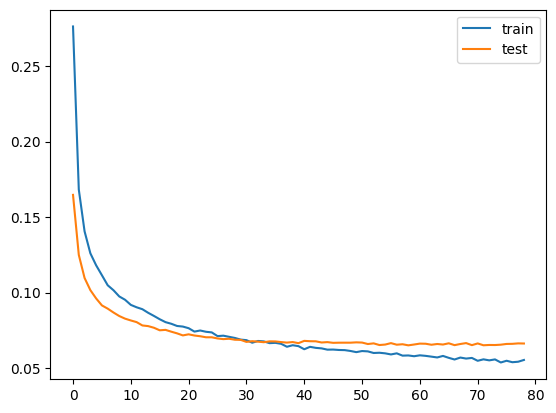

In [ ]:
from matplotlib import pyplot
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()


## Questions
1. What can you say about the way the loss function change?
2. Now turn off the early stopping. How does it change?
3. Now, using the train and validation test, tune the hyperparameter. When you are ready, get the final performance on your test test set.

In [ ]:
model.evaluate(test_ds)

62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7865 - loss: 0.0908 - macro_F1: 0.7679 - top_2_categorical_accuracy: 0.9181


[0.09564239531755447,
 0.7844739556312561,
 0.7922413349151611,
 0.912155270576477]

## Conclusions

The test set must only be used once you have chosen the model and set the hyperparameter. Otherwise you can start overfitting to your test set as well.

This whole practical was meant to give you some basic skill to be able to clean your data before launching an analysis, then to set up some basic model. There is much more we could do to improve what we have done.

To go further, you can start exploring how other people do it, or participate in competition on https://www.kaggle.com.